# Foundations of Large Language Models

**You’ll learn**: how attention works, what logits/probabilities mean, how to measure perplexity (model “surprise”), what context windows do, and why embeddings capture semantic meaning.

**Prereqs:**

- Basic Python
- A browser
- (Optional) Google Colab (CPU is fine)

**What to submit:**

1. A short Lab Report with screenshots/outputs requested below, plus brief reflections.
1. Any small code edits you made.


## Lab 1 — Build Scaled Dot-Product Attention (by hand) (20–25 mins)

**Goal**: See exactly how queries, keys, and values produce attention weights.

**Setup**


In [3]:
#!pip install -q numpy matplotlib
import numpy as np, matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

**Steps**

1. **Toy embeddings**


In [4]:
X = np.array(
    [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]]  # token 1  # token 2  # token 3
)  # shape (seq=3, d_model=3)
Wq = np.random.randn(3, 3)
Wk = np.random.randn(3, 3)
Wv = np.random.randn(3, 3)
Q, K, V = X @ Wq, X @ Wk, X @ Wv

a. **Definition of the matrix x**

- X represents the input embeddings of a sequence of 3 tokens.
- Each row is the vector of a token > d_model = 3 (embedding dimension).
- Therefore, the shape of X is (3, 3) > (seq_len, d_model).

b. **Creation of projection matrices**

These are the weight matrices to generate:

- **Q (Query)** — what the token is looking for.
- **K (Key)** — what information the token provides.
- **V (Value)** — the content to pass to the next step.

Each matrix is ​​of size (d_model, d_model) = (3, 3).

c. **Calculation of Q, K, and V**

The @ operator performs matrix multiplication.

Each token (row of X) is projected into a new space using the corresponding weights.

The following are obtained:

- **Q: query** representations of each token &larr (3, 3)
- **K: key** representations of each token &larr (3, 3)
- **V: value** representations of each token &larr (3, 3)

| Tensor     | Meaning            | Shape | Calculation |
| ---------- | ------------------ | ----- | ----------- |
| X          | Input embeddings   | (3,3) | Given       |
| Wq, Wk, Wv | Projection weights | (3,3) | Random      |
| Q          | Queries            | (3,3) | X @ Wq      |
| K          | Keys               | (3,3) | X @ Wk      |
| V          | Values             | (3,3) | X @ Wv      |


2. **Scaled dot-product**


Then, in a full attention implementation, you would use Q, K, and V to calculate the attention weights with the formula:

$$ Attention(Q, K, V) = softmax(\frac{Q \cdot K^T}{\sqrt{d_K}}) \cdot V $$

X &rarr; Q, K, V

&darr;

$ Q \cdot K^T $ &rarr; similarity scores

&darr;

$ softmax(\frac{Q \cdot K^T}{\sqrt{d_K}}) $ &rarr; attention weights

&darr;

weights @ V &rarr; attention output


In [5]:
d_k = K.shape[-1]
scores = Q @ K.T / np.sqrt(d_k)  # (seq, seq)
weights = np.exp(scores) / np.exp(scores).sum(axis=-1, keepdims=True)
context = weights @ V  # (seq, d_model)
print("Attention weights:\n", weights)

Attention weights:
 [[0.13  0.262 0.607]
 [0.063 0.125 0.812]
 [0.43  0.305 0.265]]


3. **Visualize**


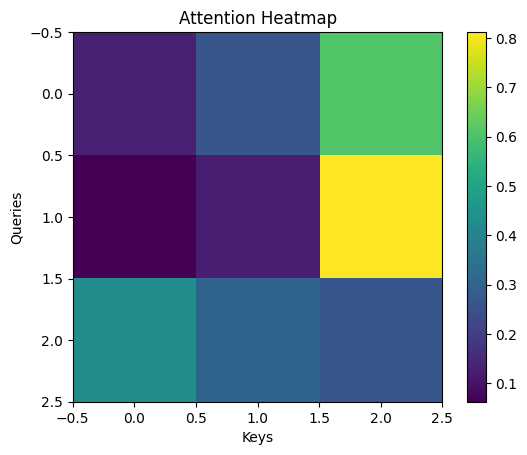

In [6]:
plt.imshow(weights, cmap="viridis")
plt.colorbar()
plt.title("Attention Heatmap")
plt.xlabel("Keys")
plt.ylabel("Queries")
plt.show()

**Checkpoint** (screenshot): the heatmap + printed weights.

**Reflection** (2–3 bullets): What does scaling by √dₖ change? How would multi-head attention extend this?


## Lab 2 — Peek Inside a Tiny LLM: Logits → Probabilities (25–30 mins)

**Goal**: Inspect next-token probabilities and see the effect of temperature/top-k/top-p.

**Setup**


In [7]:
#!pip install -q transformers torch --index-url https://download.pytorch.org/whl/cpu

# PyTorch library used for handling tensors and numerical calculations.
import torch

# Hugging Face classes that automatically download the correct tokenizer and model based on the model name.
from transformers import AutoTokenizer, AutoModelForCausalLM

# Download the pre-trained tokenizer and model distilgpt2.
tok = AutoTokenizer.from_pretrained("distilgpt2")
# This model predicts the next word/token in a text sequence (causal model).
model = AutoModelForCausalLM.from_pretrained("distilgpt2")

**Steps**

1. **Get logits for the next token**


In [8]:
prompt = "Data quality is critical because"
# Converts text to numeric tokens that the model understands.
# The return_tensors="pt" parameter returns the tokens in PyTorch tensor format.
# The output ids is a dictionary with at least one 'input_ids' key.
ids = tok(prompt, return_tensors="pt")
# print(ids)

# The torch.no_grad() function disables gradient calculations (to save memory and speed).
with torch.no_grad():
    # model(**ids) performs a forward pass and returns a structure called Modeloutput.
    # out.logits contains the probability predictions (logits) for each position in
    #  the sequence and each token in the vocabulary.
    out = model(**ids)

    # out.logits has the form (batch_size, seqg_len, vocab_size).
    # Here we select:
    #  [0]: The first (and only) element of the batch.
    #  [-1]: The last token of the prompt.
    # Therefore, logits is a vector of size equal to the vocabulary (=50,000 values),
    #  representing the unnormalized score for the next token.
    logits = out.logits[0, -1]  # last position

    # Applies softmax along the vocabulary axis > converts logits to probabilities
    #  (values ​​between 0 and 1 that add up to 1).
    # probabs[i] = probability that the next token is the token with index i.
    probs = torch.softmax(logits, dim=-1)

    # Returns the 10 indices with the highest probability and their values.
    #  topk.values ​​> probabilities.
    #  topk.indices + IDs of the corresponding tokens.
    topk = torch.topk(probs, k=10)

    # tok.decode(i) converts the token ID back to readable text.
    # The most likely token to continue the sentence and its probability are printed.
    for p, i in zip(topk.values, topk.indices):
        print(f"{tok.decode(i):>10s} {p.item():.4f}")

        it 0.1524
       the 0.1281
        of 0.0878
        we 0.0497
     there 0.0287
         , 0.0163
      they 0.0163
      most 0.0150
         a 0.0142
       our 0.0140


The model predicts that the most likely words to continue "_Data quality is critical because_" are: (check the results)

This code is a clear and compact example of how to use **Hugging Face Transformers** with **PyTorch** to inspect the token-by-token predictions of an autoregressive (causal) language model, in this case **DistilGPT-2** (a lightweight version of GPT-2).


2. **Apply temperature**


In [9]:
# next_token_probs generates the probability distribution of the next token
#  based on the model (model) and the initial text (prompt).
# It allows three types of control:
#   T > temperature (adjusts randomness).
#   top_k > keeps only the k most probable tokens.
#   top_p > keeps tokens whose cumulative probability < p (nucleus sampling).
def next_token_probs(prompt, T=1.0, top_p=1.0, top_k=0):
    ids = tok(prompt, return_tensors="pt")

    with torch.no_grad():
        logits = model(**ids).logits[0, -1] / T
        probs = torch.softmax(logits, dim=-1)

        # --- Top-k filtering ---
        if top_k > 0:
            vals, idx = torch.topk(probs, top_k)
            mask = torch.zeros_like(probs)
            mask[idx] = 1
            probs = probs * mask
            probs /= probs.sum()

        # --- Top-p (nucleus) filtering ---
        if top_p < 1.0:
            sorted_probs, idx = torch.sort(probs, descending=True)
            cumsum = torch.cumsum(sorted_probs, dim=0)
            keep = cumsum <= top_p
            keep[0] = True
            mask = torch.zeros_like(probs)
            mask[idx[keep]] = 1
            probs = probs * mask
            probs /= probs.sum()

    return probs


# --- Comparison of distributions at different temperatures ---
# Finally, the entropy of the distribution ( H(token dist) ) is measured,
#  which indicates how "flat" or "concentrated" it is:
#   Low temperatures > concentrated distribution (more deterministic model).
#   High temperatures > flatter distribution (more creative or random model).
for T in [0.2, 0.7, 1.0, 1.3]:
    p = next_token_probs(prompt, T=T)
    entropy = -(p[p > 0] * p[p > 0].log()).sum().item()
    print(f"\nT={T}  H(token dist) ≈ {entropy:.4f}")


T=0.2  H(token dist) ≈ 0.7752

T=0.7  H(token dist) ≈ 2.4007

T=1.0  H(token dist) ≈ 5.0999

T=1.3  H(token dist) ≈ 7.7034


3. **Generate short continuations** (compare strategies)


In [10]:
# Import and create the pipeline
# This code demonstrates how to use the Hugging Face Transformers
#  text generation pipeline to produce text with different sampling configurations.
# A pipeline is a high-level interface that combines:
#   The model (model)
#   The tokenizer (tok)
#   The task ("text-generation")
# and allows you to execute the entire process (tokenization > inference > decoding)
#   in a single call.
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Parameters:
#   "text-generation": indicates that we want to generate text autoregressively
#    (predicting token by token).
#   model=model: the pre-trained model (e.g., distilgpt2).
#   tokenizer=tok: the tokenizer compatible with the model.
#   device=-1: means it will use the CPU. If device=0, it will use the GPU (CUDA).
#   gen is now a ready-to-use text generator.
# --- Load the model ---
model_name = "distilgpt2"
tok = AutoTokenizer.from_pretrained(model_name)
tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name)

gen = pipeline("text-generation", model=model, tokenizer=tok, device=-1)

prompt = "Data quality is critical because"

# Define different sampling configurations
# Three configurations (three cfg dictionaries) are created here that control
#  how the model chooses the next token when generating text.
configs = [
    # Configuration 1: dict(do_sample=False)
    #   No random sampling. Uses greedy decoding > always chooses the most likely token.
    #   Result: More coherent, but repetitive or predictable text.
    dict(do_sample=False),
    # Configuration 2: dict(do_sample=True, temperature=0.7, top_p=0.9)
    #   do_sample=True : activate random sampling.
    #   temperature=0.7 : lower the temperature > sharper (less random) distributions.
    #   top_p=0.9 : applies nucleus sampling, choosing among the tokens whose
    #    cumulative probability < 0.9.
    # Favors likely tokens, but with some creativity.
    dict(do_sample=True, temperature=0.7, top_p=0.9),
    # Configuration 3: dict(do_sample=True, temperature=1.0, top_k=50)
    #   temperature=1.0: no adjustment, distributions as given by the model.
    #   top_k=50: the model can only choose from the 50 most likely tokens.
    # More controlled than top_p, but maintains variety.
    dict(do_sample=True, temperature=1.0, top_k=50),
]
for cfg in configs:
    # Generate text
    #   prompt : The initial text, for example "Data quality is critical because".
    #   max_new_tokens=60 : The maximum number of tokens the model will
    #    generate after the prompt.
    #   **cfg : Applies the current configuration parameters
    #     (do_sample, temperature, top_p, etc.).
    #     gen(...) returns a list of results; we take the first [0] and
    #      extract the generated text with ["generated_text"].
    out = gen(prompt, max_new_tokens=60, **cfg)[0]["generated_text"]

    # The configuration used and the text generated by the model are printed.
    print("\nCFG:", cfg, "\n", out)

Device set to use cpu
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



CFG: {'do_sample': False} 
 Data quality is critical because it is not a good predictor of the quality of the data.
















































CFG: {'do_sample': True, 'temperature': 0.7, 'top_p': 0.9} 
 Data quality is critical because most of the time it’s not a good idea.

CFG: {'do_sample': True, 'temperature': 1.0, 'top_k': 50} 
 Data quality is critical because both major states have a high proportion of high school-age Hispanic students who are also younger than the average age of white students.

























The study authors did not find that these


**Checkpoint:**

- Top-10 next-token list for the baseline.
- 2–3 continuations showing style changes.

**Reflection** (3–5 bullets): How did temperature change entropy/diversity? Which sampling setting balanced sense vs creativity?


## Lab 3 — Perplexity & Context Window Behavior (25–35 mins)

**Goal**: Measure how “surprised” a model is (perplexity) and see what happens near/over the max context.

**Setup**

1. **Perplexity function**


In [11]:
# This block calculates the perplexity of a text based on a language model
#  (e.g., GPT-2).
# Perplexity (PPL) measures how well the model predicts a text.
#  The lower the PPL, the better the model "understands" or fits that text.
import math
import torch


def perplexity(text, stride=512):
    # Tokenize the text
    enc = tok(text, return_tensors="pt")
    input_ids = enc["input_ids"]
    max_pos = model.config.n_positions  # GPT-2: 1024
    lls, n_tokens = [], 0

    for i in range(0, input_ids.size(1), stride):
        # Split long text into windows ( stride ) to stay within
        #  the maximum model size ( max_pos ).
        begin = max(i + stride - max_pos, 0)
        end = min(i + stride, input_ids.size(1))
        trg_len = end - i

        input_ids_window = input_ids[:, begin:end]
        target_ids_window = input_ids_window.clone()
        target_ids_window[:, : i - begin] = -100
        # inp_ids = input_ids[:, begin:end]
        # tgt_ids = input_ids[:, i:end]

        # For each window:
        # Calculate the model's loss for those tokens.
        # Multiply by the number of tokens to weight correctly.
        with torch.no_grad():
            outputs = model(input_ids_window, labels=target_ids_window)
            lls.append(outputs.loss.item() * trg_len)
        n_tokens += trg_len

        if end == input_ids.size(1):
            break

    # Average the loss per token and apply exp() > get the total perplexity.
    ppl = math.exp(sum(lls) / n_tokens)
    return ppl, n_tokens, max_pos


good_text = "In data engineering, data quality ensures reliable analytics, governance, and trust…"
bad_text = (
    "Quality data banana spark plug arithmeticly frobnicate sevenly times howeverly…"
)

print("Good:", perplexity(good_text))
print("Bad :", perplexity(bad_text))

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Good: (342.5955896342423, 15, 1024)
Bad : (31972.15294912749, 16, 1024)


2. **Context window check**


In [ ]:
# This code snippet is a stress test to measure how a language model (such as GPT-2)
#  handles long texts and how the perplexity function behaves.

# Generates a text string by repeating "This is a token." 1200 times.
# Each repetition has multiple tokens (words and punctuation), so the final text
#  exceeds the maximum context limit of the GPT-2 model (=1024 tokens).
long_text = ("This is a token. ") * 1200  # ~exceeds 1024 tokens

# GPT-2 and derivatives have an n_positions parameter that defines the maximum number
#  of tokens they can process at once.
# When creating a text longer than this limit, we test that the perplexity() function
#  is able to split it into manageable-length windows.

# Call the perplexity() function, which evaluates how well the model "predicts"
#  the given text.
# Within perplexity() , the text is tokenized, passed through the model in
#  stride blocks, and the loss (average cross entropy) is calculated for each block.
# Finally, the following is applied:
#                 Perplexity = e ^ (average loss)
# Interpretation of the result:
#   Low perplexity (e.g., <50):
#     The model considers the text to be natural, coherent, and predictable.
#   High perplexity (e.g., >300):
#     The text appears improbable or incoherent.
ppl_long = perplexity(long_text)

# ppl_long > the tuple that the function returns:
#   (perplexity_value, n_tokens, max_pos)
# perplexity value: The numerical measure of how well the model predicted the text.
# n_tokens: The total number of tokens processed.
# max_pos: The maximum limit of the model (e.g., 1024 for GPT-2).
# model.config.n_positions -> confirms how many tokens the model can process
#  in a single pass.
print("Long text PPL & tokens:", ppl_long)
print("Model max positions:", model.config.n_positions)

**Checkpoint**: printed PPL for “good” vs “bad” text; note token counts and max context.

**Reflection** (3–4 bullets): When text exceeds the window, what does the function do? Why does PPL differ for coherent vs gibberish?


## Lab 4 — Embeddings 101: Meaning as Vectors (25–30 mins)

**Goal**: Generate sentence embeddings and see semantic similarity in action.

**Setup**


In [ ]:
#!pip install -q sentence-transformers scikit-learn

# SentenceTransformer: A pre-trained model that converts text into
#  semantic embeddings (vectors that capture meaning).
from sentence_transformers import SentenceTransformer

# cosine_similarity: A scikit-learn function that measures the similarity
#  between vectors (how closely they are aligned).
from sklearn.metrics.pairwise import cosine_similarity

# numpy: Used to manipulate matrices and set printing options.
import numpy as np

# This model (all-MiniLM-L6-v2) is a transformer optimized for
#  generating representations (embeddings) of sentences in a 384-dimensional space.
#  It is trained to ensure that sentences with similar meanings have vectors
#  that are close together (high cosine similarity).
# In short: it converts text > a number that represents its "meaning."
model_s = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

**Steps**

1. **Create a small corpus**


In [ ]:
# Here are 6 sentences on three different topics:
#  Aviation / maintenance > sentences 1 and 5
#  Agriculture / hydroponics > sentences 3 and 4
#  Business / marketing > sentences 2 and 6
# This will help us see if the model groups well by topic.
sentences = [
    "Monitor aircraft maintenance logs for anomaly detection.",
    "We analyzed sales trends across regions using SQL.",
    "Grow basil and lettuce indoors with hydroponics.",
    "Vertical farming increases yield per square foot.",
    "The engine vibration patterns indicate possible imbalance.",
    "Marketing mix models estimate channel impact on revenue.",
]
# Converts each sentence into a numeric vector (embedding) of size 384.
# normalize_embeddings=True ensures that each vector has norm 1,
#  which simplifies the calculation of the cosine
#  (since it is equivalent to the dot product).
# The result E is a matrix of shape (6, 384).
E = model_s.encode(sentences, normalize_embeddings=True)

# Calculate the cosine similarity between each pair of sentences:
#      sim(A, B) = (A . B) / (||A|| ||B||)
# Since all embeddings are normalized, the result varies between:
#  1.0 > identical sentences or sentences with the same meaning
#  0.0 > unrelated
#  -1.0 > opposite meanings (rare in natural text)
# The result S is a 6x6 matrix (diagonal symmetry with 1.0 values).
S = cosine_similarity(E)

# Displays values ​​with two decimal places (precision=2)
# suppress=True avoids scientific notation (e.g., 1e-05)
np.set_printoptions(precision=2, suppress=True)

print(S)

2. **Top semantic neighbors**


In [ ]:
# Here what you do is look for the sentences most similar to each sentence in the set,
#  using the similarity matrix s.
for i, s in enumerate(sentences):
    # S[i] is the vector of similarities between sentence i and all other sentences
    #  (including itself).
    # np.argsort() returns the indices sorted from lowest to highest.
    # The - sign reverses the order, from highest to lowest similarity.
    idx = np.argsort(-S[i])

    print(f"\nQuery: {s}\nNearest:", [sentences[j] for j in idx[1:3]])

3. **Quick clustering**


In [ ]:
# KMeans: It is an unsupervised learning algorithm that groups points
#  (here, embeddings) into a fixed number of clusters k.
from sklearn.cluster import KMeans

# n_clusters=3 + we want 3 clusters (e.g., aviation, agriculture, marketing).
# n_init=10 > Runs the algorithm with 10 different initializations
#  to avoid local minima.
# random_state=0 > Ensures reproducible results.
# .fit_predict(E):
#   Fits the model to the vectors E (the representations of each sentence).
#   Returns a labels array where each value indicates which cluster
#    each sentence belongs to.
labels = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(E)

# Iterate through the three clusters (c = 0, 1, 2).
# For each cluster:
#   Iterate through all the sentences and their labels (i, 1).
#   If label l matches the number in cluster c, print the corresponding sentence.
for c in range(3):
    print("\nCluster", c, "->")
    for i, l in enumerate(labels):
        if l == c:
            print(" ", sentences[i])

**Checkpoint**: similarity matrix snippet + printed nearest neighbors.

**Reflection** (2–3 bullets): Which pairs clustered together and why? Any "surprises"


## Lab 5 — Masked vs Causal LMs (10–15 mins)

**Goal**: Contrast BERT’s fill-mask with GPT-style free generation.

**Steps**


In [ ]:
from transformers import pipeline

fill = pipeline("fill-mask", model="bert-base-uncased")
print(fill("The capital of France is [MASK]."))

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tok2 = AutoTokenizer.from_pretrained("distilgpt2")
m2 = AutoModelForCausalLM.from_pretrained("distilgpt2")
ids = tok2("The capital of France is", return_tensors="pt")
out = m2.generate(**ids, max_new_tokens=5, do_sample=False)
print(tok2.decode(out[0]))

**Linguistic Reason**:

- GPT-2 has no explicit factual knowledge (it wasn't trained with labels indicating that "Paris" is the capital of France).
- It only learns statistical patterns from English text.
- So the model completes the sentence with what it has most likely seen in its corpus.

If you want the model to correctly answer ("Paris"), you have several options, one of which is to use a larger model:


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tok2 = AutoTokenizer.from_pretrained("gpt2-medium")
m2 = AutoModelForCausalLM.from_pretrained("gpt2-medium")
ids = tok2("The capital of France is", return_tensors="pt")
out = m2.generate(**ids, max_new_tokens=5, do_sample=False)
print(tok2.decode(out[0]))

**Checkpoint**: one fill-mask result and one causal continuation.

**Reflection** (2–3 bullets): How do the objectives differ (masked vs next-token)? When would you use each?

### Grading Rubric (10 pts)

- Attention & logits understanding (4 pts): correct computations/interpretations +
  screenshots.
- Perplexity & context window (3 pts): PPL computed, behavior near max context
  explained.
- Embeddings (3 pts): similarity analysis with brief rationale.


### Troubleshooting

- **Slow?** Keep prompts short; CPU-friendly models used here run fine on Colab.
- **Import errors?** Restart runtime after installs.
- **Weird generations?** Adjust temperature/top_p/top_k and limit max_new_tokens.
